# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

In [ ]:
# A Function to Display Tensors Nicely (Feel Free to Skip This)
import torch
import torch.nn as nn
import torch.nn.functional as F

# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# Pytorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor


# **Chapter 20: 学習率**

### **Section 1: 学習率を大きくする**

今回の目的は、学習率と学習の不安定性の関係を体験することです。

長時間のモデル学習は行いません。だいたいモデル学習は合計で20分くらいです。

#### ⚡ T4 GPUでの効率的な学習データ準備

システムRAMの逼迫を防ぐため、今回も`fineweb.txt`を事前にトークンID列に変換した`fineweb.npy`をメモリマップで読み込みます。

前回作成したものを以下のURLに保存してあるので、これをダウンロードしてください。

```plain
https://huggingface.co/datasets/HayatoHongo/fineweb_npy/blob/main/fineweb.npy
```


⚠️注意：`blob` を `resolve` に変更することを忘れないでください！

In [ ]:
# TODO: !wget URL

**`Check Point`** <label><input type="checkbox">URLに関して`blob`ではなく`resolve`を用いた</label>

`DataLoader`クラスはChapter19と完全に同じです。

In [ ]:
import torch
import numpy as np
import tiktoken

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）

        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab
        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")

        # 訓練・検証用データの範囲を決める（実データは共有）
        self.train_data, self.val_data = self.split_data()

    def split_data(self):
        # データを 90%:10% に分割し、インデックス範囲で保持
        split_index = int(0.9 * len(self.data))

        return (0, split_index), (split_index, len(self.data))


    def get_batch(self, split):

        # 指定された split ('train' or 'val') からランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。

        # splitに応じたデータ範囲を取得
        range_start, range_end = (
            self.train_data if split == 'train' else self.val_data
        )

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

モデル関連のクラスもChapter12と同じです。ずっと変わってませんね。

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # 位置埋め込み層
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # 入力テンソル input_indices の形状：[バッチサイズ、シーケンス長]。
        sequence_length = input_indices.shape[1]

        # シーケンス長に応じた位置インデックスを作成する（例：[0, 1, 2, ..., sequence_length-1]）
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # 位置インデックスの埋め込みベクトルを取得する
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings

class EmbeddingModule(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # 各トークンの埋め込み層
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)  # 単語埋め込み層
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # 位置情報を埋め込む

    def forward(self, input_indices):
        # トークン埋め込みを取得
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # 位置埋め込みを取得する
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # トークン埋め込みと位置埋め込みを追加する
        embeddings = position_embeddings + token_embeddings
        return embeddings


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

        self.head_size = head_size

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.embedding = EmbeddingModule(vocab_size, config=config)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

`Trainer`クラスを定義します。Chapter16と完全に同じです。

In [ ]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.config.total_training_steps+1):
            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == 0:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

                print(
                    f"step {step:05d} | "
                    f"train loss {eval_loss['train']:.4f} | "
                    f"val loss {eval_loss['val']:.4f} | "
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                    f"tokens {total_seen_tokens:,} | "
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
            train_loss = self.train_step()

学習を早めるための単純なアイデアとして、学習率を高くするのはどうでしょうか？

学習率を今までの 0.001(1e-3) から 0.01(1e-2) に10倍に増やします。

In [ ]:
# モデル設定を保存する設定クラス
class ModelConfig:
    batch_size = 16
    input_sequence_length = 512  # データロードにかかる時間の割合を下げるため、長めのシークエンスを一度に取り出す。
    ########## NEW ##########
    total_training_steps = 500  # おおよそ5分くらいかかる
    ########## NEW ##########
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    evaluation_frequency = 100  # モデル性能評価の頻度
    ########## NEW ##########
    learning_rate = # TODO: 学習率 # 1e-2
    ########## NEW ##########
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 512  # 埋め込み層サイズ（特徴ベクトルの次元数）
    hidden_dim = 1024
    num_attention_heads = 8  # アテンションヘッドの数
    layer_count = 4  # モデルの層数
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [ ]:
# 設定を読み込みシードを設定する
config = ModelConfig()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

⚠️注意：もし以下のセルでエラーが生じる場合は、`fineweb.npy`のダウンロードで`blob`を`resolve`に置き換え忘れている可能性があります。既存の`fineweb.npy`を削除した後、正しいURLで再度ダウンロードしてください。

In [ ]:
data_loader = DataLoader(npy_path="/content/fineweb.npy", config = config)

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
# モデルのパラメータ数を表示する
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

それでは学習スタート！今回は500ステップだけなので5分で終わります。

前回の学習ログのcsvファイルと見比べてください。

結論から言うと訓練誤差も検証誤差はほとんど下がりません。

学習率を大きくしたのに、かえって学習が進みづらくなるのはなぜでしょうか？



In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

**学習率を上げても学習が進まない理由**

学習率を上げると更新幅が大きくなり、最適値に早く近づけるように見えます。

しかし、更新幅が大きすぎると、細かい調整ができなくなります。

その結果、学習が安定せず、停滞してしまうのです。


対策は2つ

1. **バッチサイズを大きくする**

   学習は安定しますが、T4 GPUでは限界があります。
   
   ＊ バッチサイズを大きくすると学習が安定するメカニズムの説明は複雑なので省略します。

   
2. **学習率を下げる**

   学習が安定しますが、学習率を下げすぎると更新幅が小さすぎて学習が遅くなります。


#### 実践的な方法

最適な学習率（learning rate）は、最終的には**実験によって決定する**のが一般的です。
いくつかの候補値を短いステップで試し、損失関数の収束具合や安定性を観察したうえで、有望な値を本格的な学習に用います。

再現実験（replication experiments）の場合、多くは**元論文の著者が学習率を明記**しているため、自分で最適化を試す機会はそれほど多くありません。

---

#### 小規模環境での注意点

このノートブックではGPUのメモリ（VRAM）が限られているため、**バッチサイズを16**に制限する必要があります。

一般的に、バッチサイズが小さいと学習が不安定になりやすいです。

安全のためには
- **学習率を小さめに設定**（例：1e-4〜5e-4）し、
- **より長い訓練時間を確保**

するのが推奨されます。

ただし本ノートブックでは計算時間も限られているため、**1e-3 の比較的高い学習率**をあえて使用します。

初期の収束は速くなりますが、一般的には**不安定化のリスクがある高い学習率である**点に注意してください。

---

#### Fine-tuning時の学習率

後の章で扱いますが、**Fine-tuning（微調整）**の際は事前学習（pretraining）よりも**1桁以上小さい学習率**を用いるのが一般的です。

これは、大きな学習率を使うと**既存モデルの知識や挙動を破壊してしまう**恐れがあるためです。
したがって、Fine-tuningでは通常 **1e-4 以下**の範囲から始めるのが安全です。


### **Section 2: モデルを大きくする（読むだけ）**



学習率を`0.001`に戻します。バッチサイズは引き続き16です。

埋め込み次元数が512の場合、特に問題なく学習できます。

ここで、埋め込み次元数を512からさらに1024に増やします。

学習には時間がかかるので、今回は学習結果だけを示します。

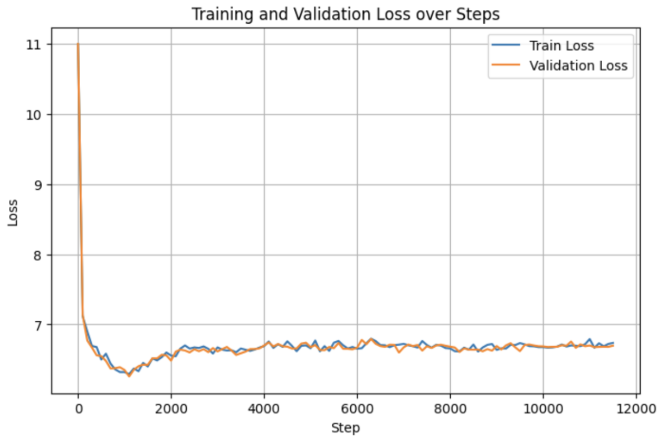

「埋め込み次元数を増やしただけなのに学習がうまくいかなくなっちゃったよ😭、、、」

なぜ学習が停滞してしまったのでしょう？

一見すると、過学習に思うかもしれませんが、もちろんデータ量は十分にあるので過学習ではありません。

これ、実は難しいです。

詳細を解説するのはたいへんなので、割愛させてください。🙇‍♂️

なお、学習率を 0.001 (1e-3)から、0.0005 (5e-4) に引き下げると解決します。

ほとんどの場合、モデルサイズを大きくする場合は学習率を下げるか、あるいはバッチサイズを大きくする必要がある、と覚えてください。


このChapterのまとめ

- 学習率が大きすぎると、学習が不安定になる
- モデルサイズが大きくなると、同じ学習率でも学習が不安定になりやすい
- 学習が不安定化した場合には、学習率を下げるか、バッチサイズを大きくするかで対応する


**Section 2: モデルを大きくする（読むだけ）** <label><input type="checkbox"> Mark as Done</label>

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 20: 学習率** <label><input type="checkbox"> Mark as Done</label>